# TP0 : Optimization of Machine Learning Problems

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)

## Objectives
1. Understand gradient descent

## Setup

Run the cell below to install and import the required packages.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

from l2math import (
    plot_gradient_descent_1d,
    plot_loss_history,
    plot_predictions,
    plot_gradient_step,
    print_model_params,
    generate_linear_data,
)

print("Setup complete!")

Setup complete!


---
# Part 1: Understanding Gradient Descent

**Goal:** Find the value of $\theta$ that minimizes a function $f(\theta)$.

## The Key Idea

Gradient descent is an iterative optimization algorithm:

$$\theta_{new} = \theta_{old} - \eta \cdot \nabla f(\theta_{old})$$

Where:
- $\theta$ is the parameter we want to optimize
- $\eta$ (eta) is the **learning rate** (step size)
- $\nabla f(\theta)$ is the **gradient** (derivative) of the function

## Example Function

Let's minimize $f(\theta) = (3\theta - 7)^2$

**Question:** What is the analytical minimum of this function?

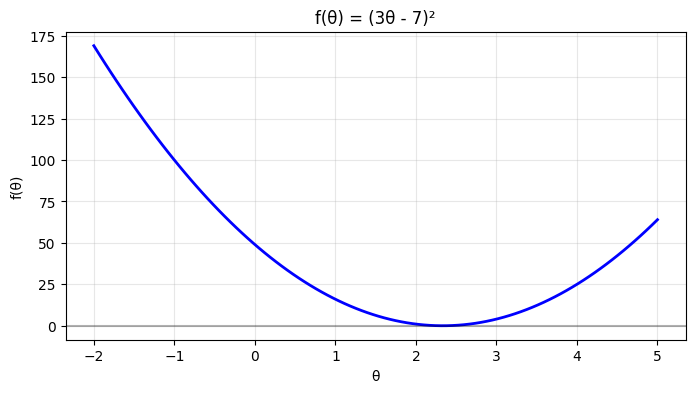

Analytical minimum: θ = 7/3 ≈ 2.3333


In [2]:
# Define the function and its gradient
def f(theta):
    """Function to minimize: (3*theta - 7)^2"""
    return (3 * theta - 7) ** 2

def gradient_f(theta):
    """Gradient of f: d/d_theta [(3*theta - 7)^2] = 2*(3*theta - 7)*3 = 6*(3*theta - 7)"""
    return 6 * (3 * theta - 7)

# Visualize the function
theta_values = np.linspace(-2, 5, 100)
plt.figure(figsize=(8, 4))
plt.plot(theta_values, [f(t) for t in theta_values], 'b-', linewidth=2)
plt.xlabel('θ')
plt.ylabel('f(θ)')
plt.title('f(θ) = (3θ - 7)²')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.show()

print(f"Analytical minimum: θ = 7/3 ≈ {7/3:.4f}")

## Gradient Descent Step by Step

Let's watch one gradient descent step in detail:

Current θ = 0.0
Current f(θ) = 49.0
Gradient at θ: -42.0

Update: θ_new = θ - lr × gradient
        θ_new = 0.0 - 0.05 × -42.0
        θ_new = 2.1


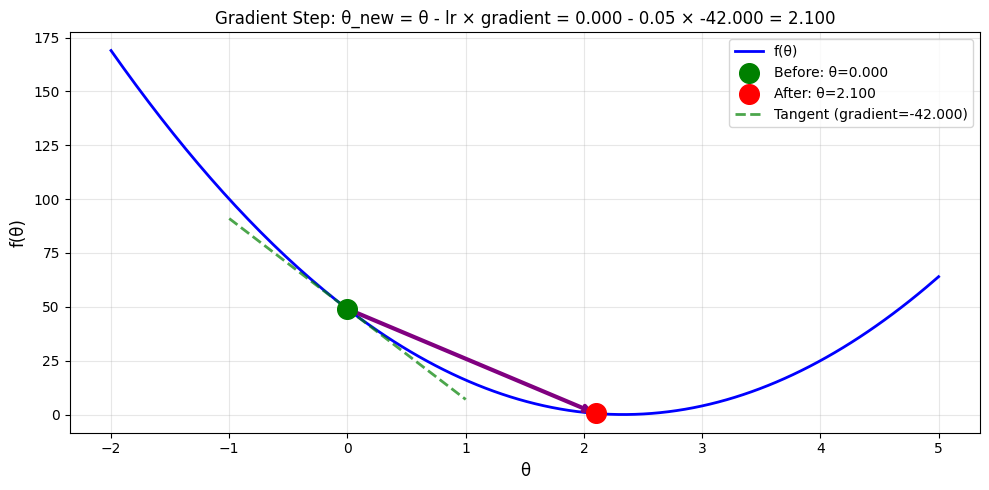

In [3]:
# Start at theta = 0
theta = 0.0
learning_rate = 0.05

# Compute gradient at current position
grad = gradient_f(theta)
print(f"Current θ = {theta}")
print(f"Current f(θ) = {f(theta)}")
print(f"Gradient at θ: {grad}")
print(f"\nUpdate: θ_new = θ - lr × gradient")
print(f"        θ_new = {theta} - {learning_rate} × {grad}")
print(f"        θ_new = {theta - learning_rate * grad}")

# Perform update
theta_new = theta - learning_rate * grad

# Visualize the step
plot_gradient_step(theta, theta_new, grad, learning_rate, f, theta_range=(-2, 5))
plt.show()

## Complete Gradient Descent

Now let's run multiple iterations:

Starting θ: 0.0000
Final θ: 2.3333
True minimum: 2.3333


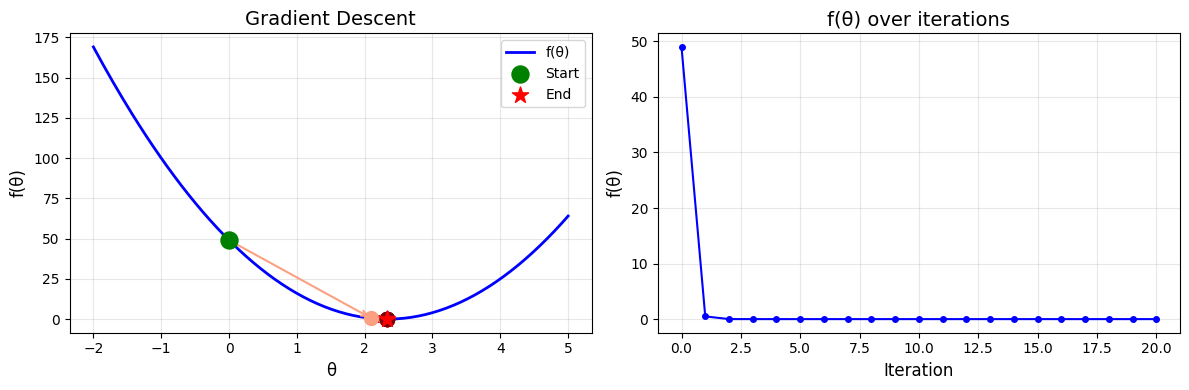

In [4]:
def gradient_descent(f, gradient_f, theta_init, learning_rate, n_iterations):
    """
    Perform gradient descent optimization.
    
    Args:
        f: Function to minimize
        gradient_f: Gradient of f
        theta_init: Starting value
        learning_rate: Step size
        n_iterations: Number of steps
    
    Returns:
        theta_history: List of theta values at each step
    """
    theta = theta_init
    theta_history = [theta]
    
    for i in range(n_iterations):
        grad = gradient_f(theta)
        theta = theta - learning_rate * grad
        theta_history.append(theta)
        
    return theta_history

# Run gradient descent
theta_history = gradient_descent(
    f=f,
    gradient_f=gradient_f,
    theta_init=0.0,
    learning_rate=0.05,
    n_iterations=20
)

print(f"Starting θ: {theta_history[0]:.4f}")
print(f"Final θ: {theta_history[-1]:.4f}")
print(f"True minimum: {7/3:.4f}")

# Visualize
plot_gradient_descent_1d(f, theta_history, theta_range=(-2, 5))
plt.show()

---
## Exercise 1: Experiment with Learning Rate

Try different learning rates and observe the behavior:
- `learning_rate = 0.01` (small)
- `learning_rate = 0.05` (medium)
- `learning_rate = 0.15` (large)
- `learning_rate = 0.35` (too large?)

**Questions:**
1. What happens with a very small learning rate?
2. What happens with a very large learning rate?
3. What is a good learning rate for this problem?

Learning rate: 0.05
Final θ: 2.3333 (target: 2.3333)


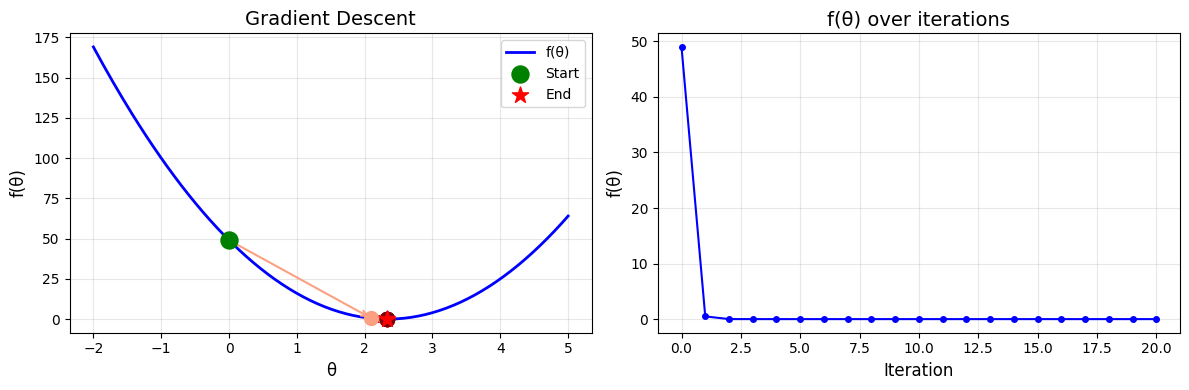

In [5]:
# TODO: Try different learning rates
learning_rate = 0.05  # <-- Modify this value!

theta_history = gradient_descent(
    f=f,
    gradient_f=gradient_f,
    theta_init=0.0,
    learning_rate=learning_rate,
    n_iterations=20
)

print(f"Learning rate: {learning_rate}")
print(f"Final θ: {theta_history[-1]:.4f} (target: {7/3:.4f})")
plot_gradient_descent_1d(f, theta_history, theta_range=(-2, 5))
plt.show()

---
## Exercise 2: Try a Different Function

Modify the function to minimize. Try: $f(\theta) = \theta^2 + 5\theta + 6$

**Hint:** The gradient is $\nabla f(\theta) = 2\theta + 5$

Analytical minimum: θ = -2.5
Final θ: -2.4907


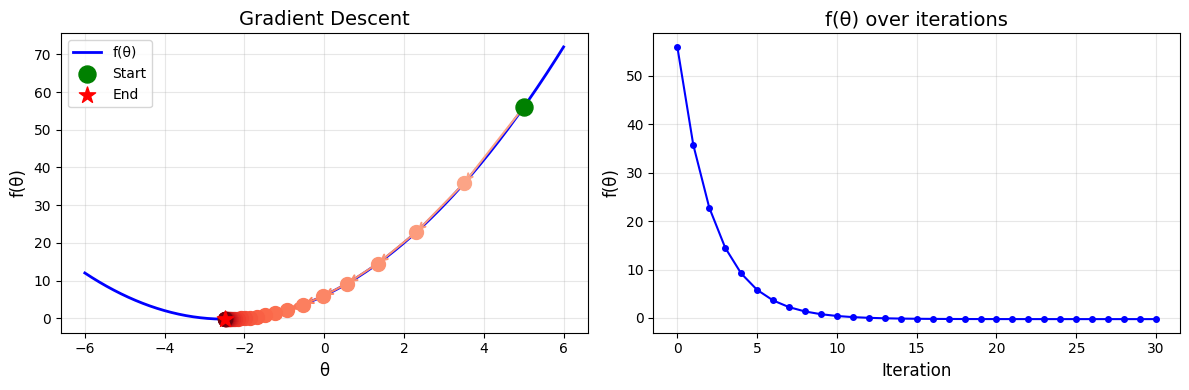

In [6]:
# TODO: Define a new function and its gradient
def f2(theta):
    return theta**2 + 5*theta + 6  # Modify this!

def gradient_f2(theta):
    return 2*theta + 5  # Modify this!

# What's the analytical minimum? (hint: set gradient to 0)
analytical_min = -5/2  # theta where gradient = 0
print(f"Analytical minimum: θ = {analytical_min}")

# Run gradient descent
theta_history = gradient_descent(
    f=f2,
    gradient_f=gradient_f2,
    theta_init=5.0,
    learning_rate=0.1,
    n_iterations=30
)

print(f"Final θ: {theta_history[-1]:.4f}")
plot_gradient_descent_1d(f2, theta_history, theta_range=(-6, 6))
plt.show()

---
# Part 2: Linear Regression with scikit-learn

Now we apply optimization to a real machine learning problem: **linear regression**.

**Goal:** Find weights $w$ and bias $b$ such that $\hat{y} = Xw + b$ minimizes the Mean Squared Error (MSE):

$$\mathcal{L} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

## Generate a Dataset

Generated linear dataset:
  - Samples: 100
  - Features: 1
  - X shape: (100, 1)
  - y shape: (100, 1)
  - True weights: [1.49014246]
  - True bias: 5.0000


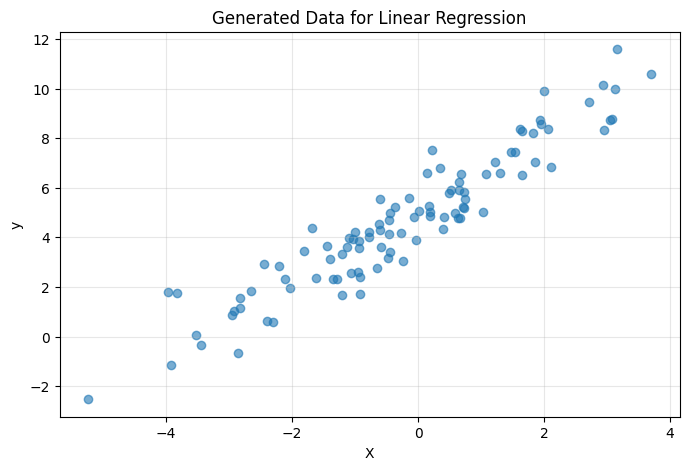

In [7]:
# Generate synthetic data
X, y, true_weights, true_bias = generate_linear_data(
    n_samples=100,
    n_features=1,
    noise=1.0,
    bias=5.0,
    weight_scale=3.0,
    seed=42
)

# Visualize the data
plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.6)
plt.xlabel('X')
plt.ylabel('y')
plt.title('Generated Data for Linear Regression')
plt.grid(True, alpha=0.3)
plt.show()

## Create a Linear Model


 Model Parameters

  weight (coef_): [1.4224116226775045]
  bias (intercept_): [5.02337880293982]

  Total parameters: 2

MSE Loss: 0.8653


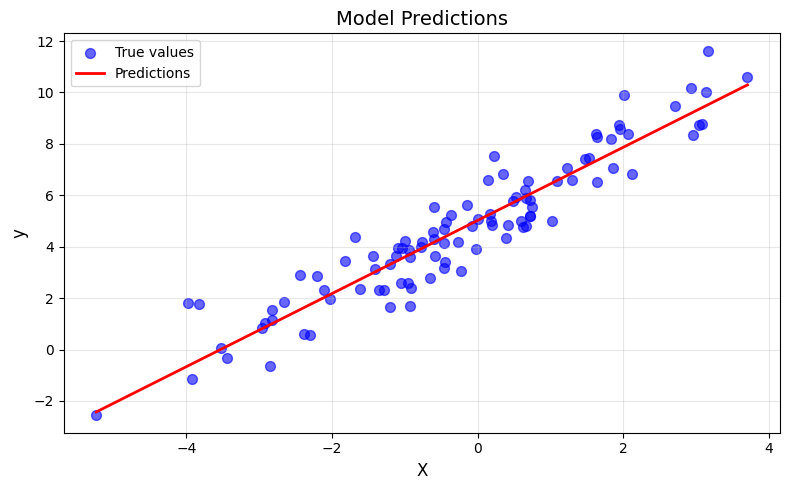

In [8]:
# Create a simple linear model: y = Xw + b
model = LinearRegression()

# Before fitting, the model has no parameters yet
# Let's fit it to see the learned parameters
model.fit(X, y)

# Show learned parameters
print_model_params(model, "Model Parameters")

# Compute predictions and loss
y_pred = model.predict(X)
mse = mean_squared_error(y, y_pred)
print(f"MSE Loss: {mse:.4f}")

# Visualize predictions
plot_predictions(X, y, y_pred, title="Model Predictions")
plt.show()

## How scikit-learn Fits a Linear Model

**Loss Function (MSE):** Measures how far predictions are from true values.
$$\mathcal{L} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

**Ordinary Least Squares (OLS):** scikit-learn's `LinearRegression` finds the optimal parameters analytically (closed-form solution) rather than using iterative gradient descent:

$$w = (X^T X)^{-1} X^T y$$

This gives the **exact** minimum of the MSE in a single step, without needing to choose a learning rate or number of epochs.

In [9]:
# Create and fit a new model
model = LinearRegression()

# Before fitting - model has no learned parameters
print("Before fitting:")
print("  LinearRegression has no coef_ or intercept_ yet")
print("  (they are created by calling .fit())")

# Fit the model in one step
model.fit(X, y)

# Show results
y_pred = model.predict(X)
mse = mean_squared_error(y, y_pred)

print(f"\nAfter fitting:")
print(f"  Weight (coef_): {model.coef_.flatten()}")
print(f"  Bias (intercept_): {model.intercept_}")
print(f"  MSE Loss: {mse:.4f}")

Before fitting:
  LinearRegression has no coef_ or intercept_ yet
  (they are created by calling .fit())

After fitting:
  Weight (coef_): [1.42241162]
  Bias (intercept_): [5.0233788]
  MSE Loss: 0.8653


## Understanding the Fit

Let's look at what `model.fit(X, y)` does in detail:

In [10]:
print("="*60)
print(" UNDERSTANDING model.fit(X, y)")
print("="*60)

# Step 1: Create the model
print("\n[STEP 1] Create model: model = LinearRegression()")
model = LinearRegression()
print("  Model created (no parameters yet)")

# Step 2: Fit the model
print("\n[STEP 2] Fit model: model.fit(X, y)")
model.fit(X, y)
print("  The model solves for optimal weights analytically")
print(f"  Learned weight (coef_): {model.coef_.flatten()}")
print(f"  Learned bias (intercept_): {model.intercept_}")

# Step 3: Make predictions
print("\n[STEP 3] Predict: y_pred = model.predict(X)")
y_pred = model.predict(X)
print(f"  Predictions shape: {y_pred.shape}")

# Step 4: Evaluate
print("\n[STEP 4] Evaluate: mean_squared_error(y, y_pred)")
mse = mean_squared_error(y, y_pred)
print(f"  MSE Loss: {mse:.6f}")

# Compare with true parameters
print(f"\n[COMPARISON]")
print(f"  Learned weight: {model.coef_.flatten()} vs True weight: {true_weights.flatten()}")
print(f"  Learned bias:   {model.intercept_} vs True bias:   {true_bias}")

print("\n" + "="*60)

 UNDERSTANDING model.fit(X, y)

[STEP 1] Create model: model = LinearRegression()
  Model created (no parameters yet)

[STEP 2] Fit model: model.fit(X, y)
  The model solves for optimal weights analytically
  Learned weight (coef_): [1.42241162]
  Learned bias (intercept_): [5.0233788]

[STEP 3] Predict: y_pred = model.predict(X)
  Predictions shape: (100, 1)

[STEP 4] Evaluate: mean_squared_error(y, y_pred)
  MSE Loss: 0.865306

[COMPARISON]
  Learned weight: [1.42241162] vs True weight: [1.49014246]
  Learned bias:   [5.0233788] vs True bias:   [5.]



## Results Summary

In [11]:
# Final results
model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)
mse = mean_squared_error(y, y_pred)

print("="*40)
print(" RESULTS")
print("="*40)
print(f"MSE Loss: {mse:.4f}")

print(f"\nLearned parameters:")
print(f"  weight: {model.coef_.flatten()}")
print(f"  bias: {model.intercept_}")
print(f"\nTrue parameters:")
print(f"  weight: {true_weights.flatten()}")
print(f"  bias: {true_bias}")

 RESULTS
MSE Loss: 0.8653

Learned parameters:
  weight: [1.42241162]
  bias: [5.0233788]

True parameters:
  weight: [1.49014246]
  bias: [5.]


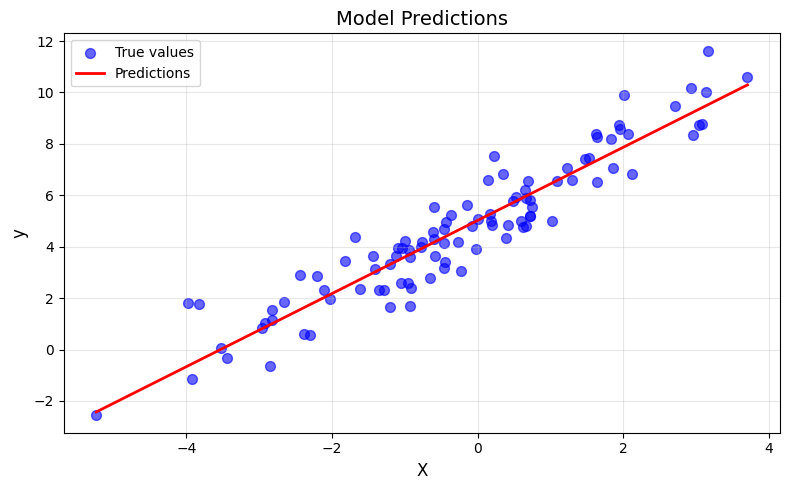

In [12]:
# Visualize predictions
plot_predictions(X, y, y_pred, title="Model Predictions")
plt.show()

---
## Exercise 3: Effect of Noise on Model Quality

Experiment with different noise levels to see how they affect the model's ability to recover the true parameters:
- `noise = 0.1` (very clean data)
- `noise = 1.0` (moderate noise)
- `noise = 5.0` (very noisy)

**Questions:**
1. How does noise affect the MSE?
2. How close are the learned parameters to the true ones with different noise levels?

Generated linear dataset:
  - Samples: 100
  - Features: 1
  - X shape: (100, 1)
  - y shape: (100, 1)
  - True weights: [1.49014246]
  - True bias: 5.0000
Noise level: 1.0
MSE: 0.865306
Learned weight: [1.42241162] (true: [1.49014246])
Learned bias: [5.0233788] (true: [5.])


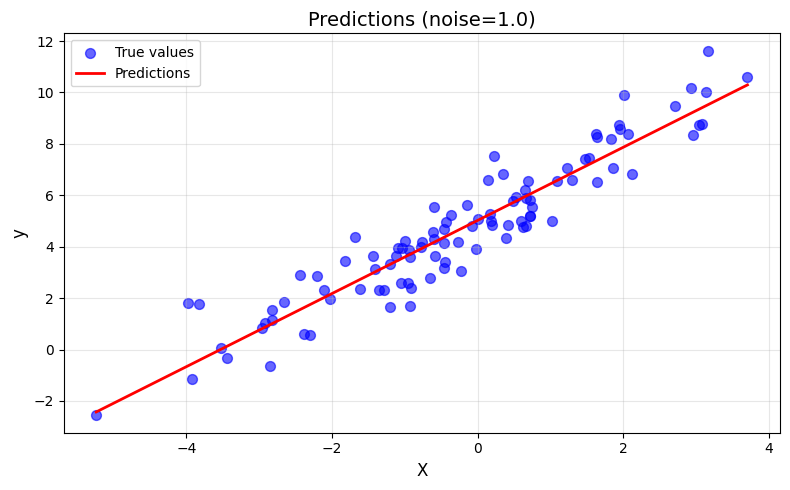

In [13]:
# TODO: Modify the noise level!
noise_level = 1.0  # <-- Try 0.1, 1.0, 5.0

X_exp, y_exp, true_w, true_b = generate_linear_data(
    n_samples=100,
    n_features=1,
    noise=noise_level,
    bias=5.0,
    seed=42
)

model_exp = LinearRegression()
model_exp.fit(X_exp, y_exp)
y_pred_exp = model_exp.predict(X_exp)
mse_exp = mean_squared_error(y_exp, y_pred_exp)

print(f"Noise level: {noise_level}")
print(f"MSE: {mse_exp:.6f}")
print(f"Learned weight: {model_exp.coef_.flatten()} (true: {true_w.flatten()})")
print(f"Learned bias: {model_exp.intercept_} (true: {true_b})")

plot_predictions(X_exp, y_exp, y_pred_exp,
                title=f"Predictions (noise={noise_level})")
plt.show()

---
## Exercise 4: Modify the Dataset

Try different dataset configurations:
- More samples: `n_samples=500`
- More noise: `noise=3.0`
- More features: `n_features=3`

**Questions:**
1. How does increasing the number of samples affect the MSE?
2. What happens with more features?

Generated linear dataset:
  - Samples: 100
  - Features: 1
  - X shape: (100, 1)
  - y shape: (100, 1)
  - True weights: [1.49014246]
  - True bias: 5.0000
Dataset: 100 samples, 1 features
MSE: 0.865306
Learned weight: [1.42241162] (true: [1.49014246])
Learned bias: [5.0233788] (true: [5.])


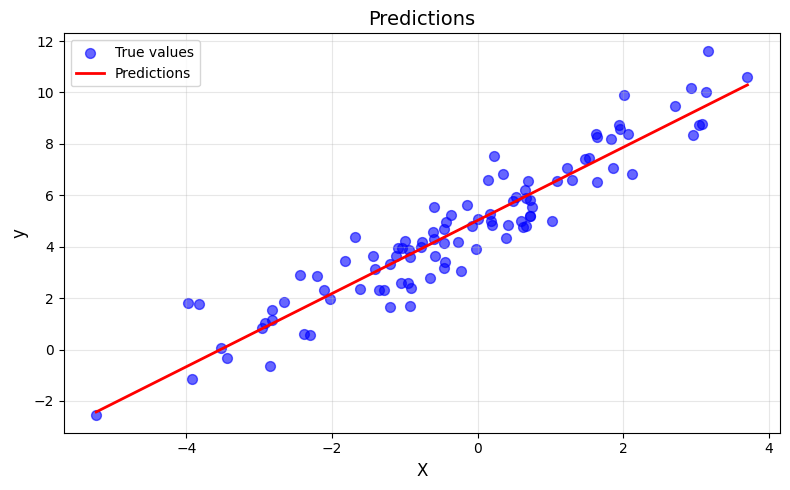

In [14]:
# TODO: Modify dataset parameters
X_new, y_new, true_w, true_b = generate_linear_data(
    n_samples=100,   # <-- Try 500
    n_features=1,    # <-- Try 3
    noise=1.0,       # <-- Try 3.0
    bias=5.0,
    seed=42
)

# Create and fit model
model_new = LinearRegression()
model_new.fit(X_new, y_new)
y_pred_new = model_new.predict(X_new)
mse_new = mean_squared_error(y_new, y_pred_new)

print(f"Dataset: {X_new.shape[0]} samples, {X_new.shape[1]} features")
print(f"MSE: {mse_new:.6f}")
print(f"Learned weight: {model_new.coef_.flatten()} (true: {true_w.flatten()})")
print(f"Learned bias: {model_new.intercept_} (true: {true_b})")

# Visualize loss comparison (only for 1D features)
if X_new.shape[1] == 1:
    plot_predictions(X_new, y_new, y_pred_new, title="Predictions")
    plt.show()